# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 

- En usuarios veo valores nulos en city y churn date. City tiene un 11.72% de valores faltantes y churn date un 88.35%.
- En usage hay valores nulos en date, duration y lenght. date tiene un 0.125% de valores faltantes, duration un 55.19% y lenght un 44.74%


**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  
-  En usuarios veo valores nulos en city y churn date. City tiene un 11.72% de valores faltantes y churn date un 88.35%.
- En usage hay valores nulos en date, duration y lenght. date tiene un 0.125% de valores faltantes, duration un 55.19% y lenght un 44.74%

- Indica qué harías: ¿imputar, eliminar, ignorar?

- para todos los casos notificaria a los jefes de la cituacion, pero en caso de churn date propondria ignorar o eliminar la columna. El porcentaje de nulos es muy alto, lo cual en teoria es bueno porque quiere decir que mucha gente NO ha cancelado su servicio. Investigaria city, duration y lenght para ver si imputo o dejo como nulos. Finalmente dejaria como nulos date dado que el porcentaje es muy bajo. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
columnas_numericas_users = users[['user_id', 'age']]
print(columnas_numericas_users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` tiene muchos numberos con la mayoria en un rango entre 10000 y 13999.
- La columna `age` tiene edades de hasta -999 lo cual es imposible.

In [13]:
columnas_numericas_usage = usage[['id', 'user_id', 'duration', 'length']]
print(columnas_numericas_usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas id y user_id varian un poco porque id tiene id que van consecutivamente del 1 al 40000, en cambio los user_id van del 10000 al 13999, son aproximadamente 4000 usuarios diferentes 

In [14]:
# explorar columnas categóricas de users
columnas_categoricas_users = users[['city', 'plan']]
print(columnas_categoricas_users.value_counts())
print(columnas_categoricas_users.describe())

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64
          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` tiene valores '?' y Na. Faltan 469 usuarios que no tienen ciudad.
- La columna `plan` se dibiden entre Basico y Premium

In [15]:
# explorar columna categórica de usage
columnas_categoricas_usage = usage[['type']]
print(columnas_categoricas_usage.value_counts())
print(columnas_categoricas_usage.describe())

type
text    22092
call    17908
dtype: int64
         type
count   40000
unique      2
top      text
freq    22092


- La columna `type` tiene dos tipos de registros, text y call. 55.2% de los registros son texto y 44.8% son llamadas. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- encontre valores invalidos en age, city. Y tengo la impresion que las fechas no estan estandarizadas. 
- ¿Qué acción tomarías?
- planeo estandarizar las fechas, y probablemente impute o elimine los balores faltantes, una vez que averigue si hay un patron entre ellos. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce")

In [18]:
# Revisar los años presentes en `reg_date` de users
years_present = users['reg_date'].dt.year.unique()
print("Años presentes:", sorted(years_present))

Años presentes: [2022, 2023, 2024, 2026]


En `reg_date`, veo datos del año 2026 lo cual no debe ser. 

In [19]:
# Revisar los años presentes en `date` de usage

print("Tipo de datos:", usage['date'].dtype)
print("Primeros valores:", usage['date'].head())


years_present = usage['date'].dt.year.unique()
print("Años presentes:", sorted(years_present))

Tipo de datos: datetime64[ns]
Primeros valores: 0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]
Años presentes: [2024.0, nan]


En `date`, veo 2024.0 y nan, un sentinel 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- si tenemos unas instencias de nan y de 2026
- ¿Qué harías con ellas?
- purgarlas


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
valores_validos = users['age'] != -999
ages_sin_centinela = users['age'][valores_validos]
age_mediana = ages_sin_centinela.median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

#print("¿Quedan valores -999?", (users['age'] == -999).any())
#print("Nueva mediana:", users['age'].median())
#print("Rango de valores:", users['age'].min(), "a", users['age'].max())

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
text_sentinels = ["?"]
users['city'] = users['city'].replace(text_sentinels, pd.NA)
# Verificar cambios
#users['city'].describe()
users['city'].value_counts(dropna=False)
#users['city'].isna().sum()

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:

# Marcar fechas futuras como NA para reg_date
fechas_futuras = users['reg_date'] > pd.Timestamp('2024-12-31')
users['reg_date'] = np.where(fechas_futuras, pd.NA, users['reg_date'])
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
# Verificar cambios
years_present_regdate = users['reg_date'].dt.year.unique()
print("Años:", sorted(years_present_regdate))


Años: [2022.0, nan, 2023.0, 2024.0]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
duration_missing = usage['duration'].isna()
crosstab_duration = pd.crosstab(usage['type'], duration_missing, margins=True)
print("Tabla de contingencia - Duration:")
print(crosstab_duration)
print()

# Porcentajes por tipo para duration
print("Porcentaje de nulos en duration por type:")
print(crosstab_duration.div(crosstab_duration.sum(axis=1), axis=0).round(3))
print()

Tabla de contingencia - Duration:
duration  False   True    All
type                         
call      17908      0  17908
text         16  22076  22092
All       17924  22076  40000

Porcentaje de nulos en duration por type:
duration  False   True  All
type                       
call      0.500  0.000  0.5
text      0.000  0.500  0.5
All       0.224  0.276  0.5



In [24]:
# Verificación MAR en usage (Missing At Random) para length
length_missing = usage['length'].isna()
crosstab_length = pd.crosstab(usage['type'], length_missing, margins=True)
print("Tabla de contingencia - Length:")
print(crosstab_length)

# Porcentajes por tipo para length
print("Porcentaje de nulos en length por type:")
print(crosstab_length.div(crosstab_length.sum(axis=1), axis=0).round(3))

Tabla de contingencia - Length:
length  False   True    All
type                       
call       12  17896  17908
text    22092      0  22092
All     22104  17896  40000
Porcentaje de nulos en length por type:
length  False   True  All
type                     
call    0.000  0.500  0.5
text    0.500  0.000  0.5
All     0.276  0.224  0.5


Hay un patron sistematico logico en la division de nulos, dado que las llamadas tienen duration y no lenght, en cambio los mensajes tienen lenght y no duration. Los nulos dependen completamente del tipo de comunicacion. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas



# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum',
                                          'is_call': 'sum', 
                                          'duration': 'sum'}).reset_index()

print(usage_agg.columns.tolist())

#usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# observar resultado
usage_agg.head(3)

['user_id', 'is_text', 'is_call', 'duration']


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
num_cols=user_profile[['user_id', 'age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']]
num_cols.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

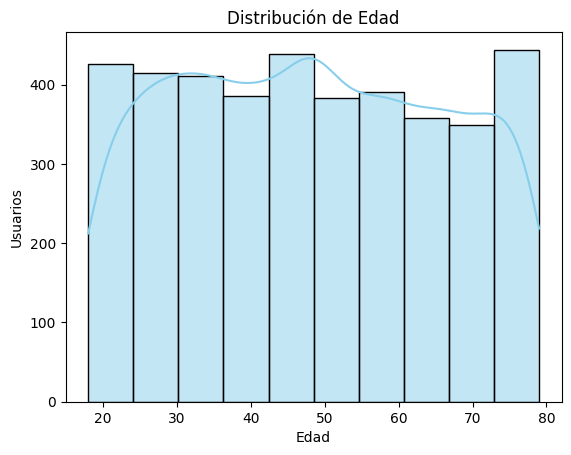

In [30]:
# Histograma para visualizar la edad (age)

sns.histplot(user_profile['age'], bins=10, color='skyblue', kde=True)

plt.xlabel('Edad')
plt.ylabel('Usuarios')
plt.title('Distribución de Edad')

plt.show()


💡Insights: 
- Distribución balanceada con una alza en los grupos de edades entre 40 y 50. junto con los usuarios entre 70 y 80.

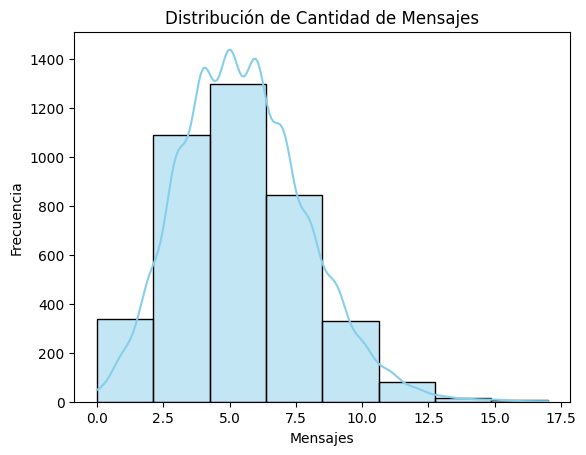

In [31]:

# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile['cant_mensajes'], bins=8, color='skyblue', kde=True)

plt.xlabel('Mensajes')
plt.ylabel('Frecuencia')
plt.title('Distribución de Cantidad de Mensajes')

plt.show()


💡Insights: 
- Distribucion con un sesgo hacia la derecha y con un alza en frecuencia en el grupo que manda entre 2 y 7 mensajes. 

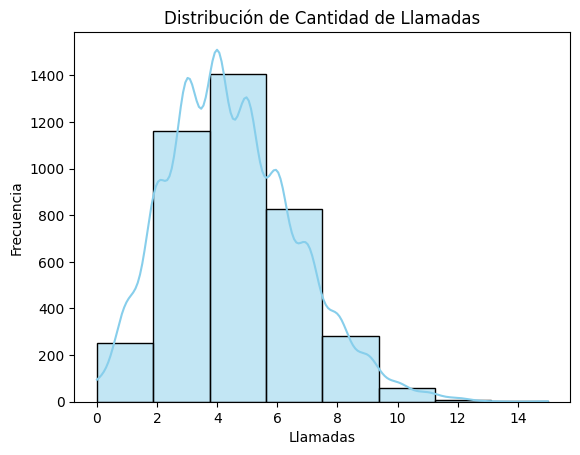

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile['cant_llamadas'], bins=8, color='skyblue', kde=True)

plt.xlabel('Llamadas')
plt.ylabel('Frecuencia')
plt.title('Distribución de Cantidad de Llamadas')

plt.show()


💡Insights: 
- Distribución con un sesgo hacia la derecha y con un alza en frecuencia en el grupo que hace entre 2 y 6 llamadas.

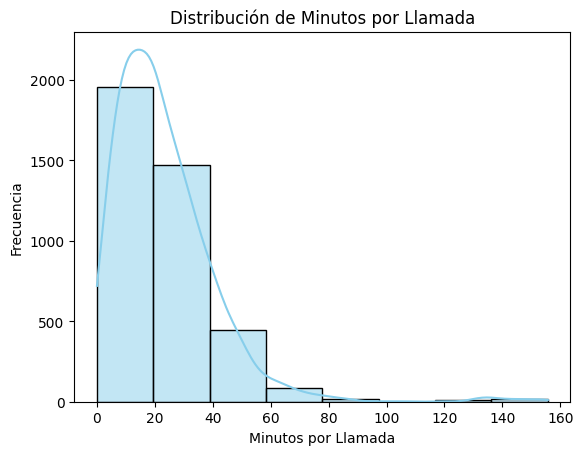

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile['cant_minutos_llamada'], bins=8, color='skyblue', kde=True)

plt.xlabel('Minutos por Llamada')
plt.ylabel('Frecuencia')
plt.title('Distribución de Minutos por Llamada')

plt.show()


💡Insights: 
- Distribución con un sesgo hacia la derecha y con un alza en frecuencia en el grupo que hace llamadas que duran entre 1 y 40 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

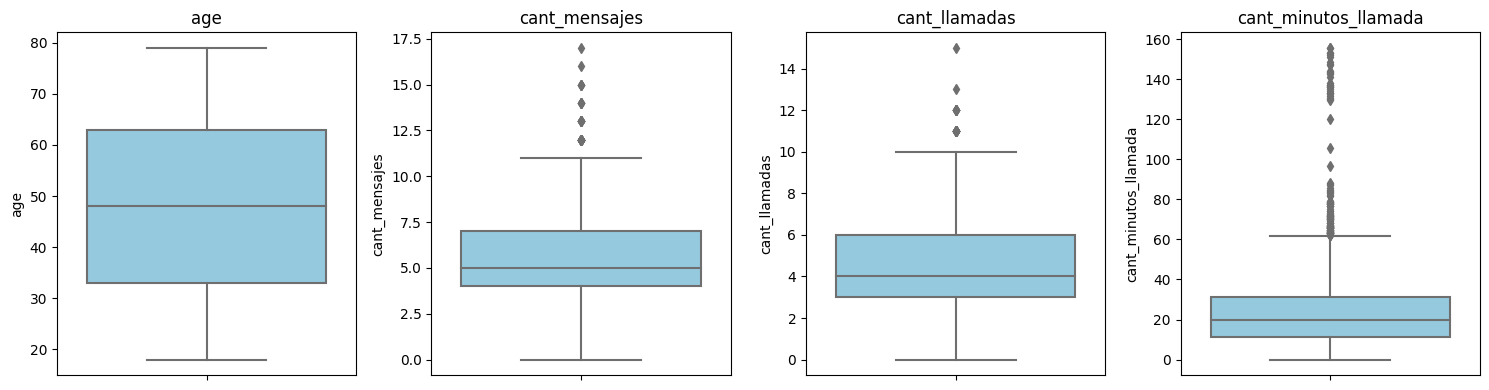

In [34]:

# Visualizando usando BoxPlot 
columnas_numericas = user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']]

plt.figure(figsize=(15, 4))
for i, col in enumerate(columnas_numericas.columns):
    plt.subplot(1, 4, i+1)  # 1 fila, 4 columnas
    sns.boxplot(y=columnas_numericas[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()
   

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Presenta outliers hacia la derecha (arriba).
- cant_llamadas: Presenta outliers hacia la derecha (arriba).
- cant_minutos_llamada: Presenta Muchos Outliers hacia la derecha (arriba).

In [35]:

# Calcular límites con el método IQR
columnas_limites = user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']]

# Calcular límites IQR para cada columna
for col in columnas_limites.columns:
    Q1 = columnas_limites[col].quantile(0.25)
    Q3 = columnas_limites[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    print(f"\n{col}:")
    print(f"  Límite inferior: {lower_limit:.2f}")
    print(f"  Límite superior: {upper_limit:.2f}")



cant_mensajes:
  Límite inferior: -0.50
  Límite superior: 11.50

cant_llamadas:
  Límite inferior: -1.50
  Límite superior: 10.50

cant_minutos_llamada:
  Límite inferior: -19.32
  Límite superior: 61.86


In [36]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
columnas_limites.describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- Creo que se pueden mantener los outliers porque no representan un sesgo tan exagerado. 
- cant_llamadas: mantener o no outliers, porqué?
- Creo que se pueden mantener los outliers porque no representan un sesgo tan exagerado. 
- cant_minutos_llamada: mantener o no outliers, porqué?
- Si pretendo utilizar winsorizacion para estos outliers, porque no es muy comun que haya llamadas telefonicas de mas de dos horas. No es imposible pero muy poco probable. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:

# Crear columna grupo_uso


def grupo_uso(user_profile):
    mensajes = user_profile['cant_mensajes']
    llamadas = user_profile['cant_llamadas']
    
    if mensajes < 5 and llamadas < 5:
        return 'Bajo uso'
    elif mensajes < 10 and llamadas < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'
        
# aplicar función y ver cambios
user_profile['grupo_uso'] = user_profile.apply(grupo_uso, axis=1)
user_profile.head()



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad

def grupo_edad(user_profile):
    
    edad = user_profile['age']
    
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
        
# aplicar función y ver cambios
user_profile['grupo_edad'] = user_profile.apply(grupo_edad, axis=1)
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

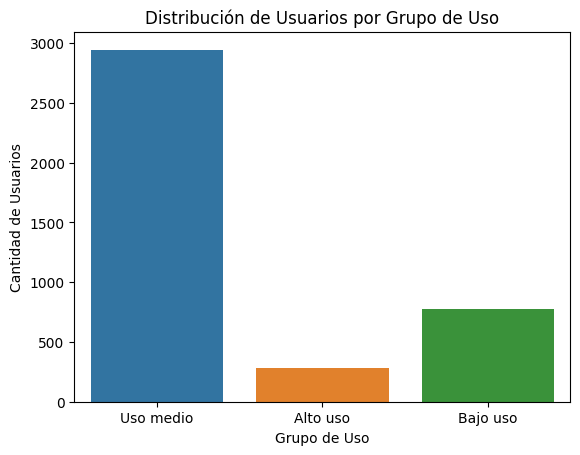

In [41]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()


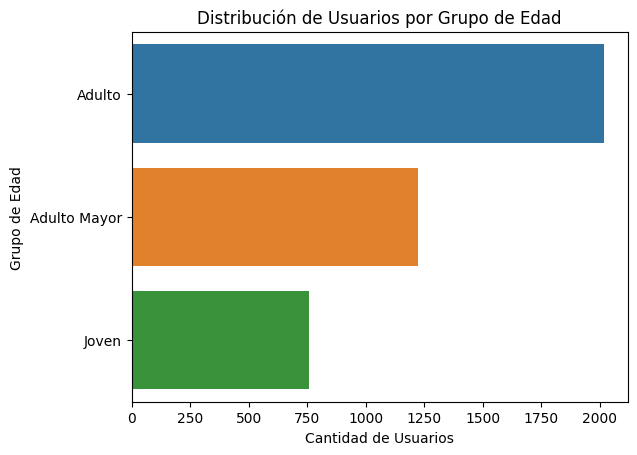

In [42]:
# Visualización de los segmentos por edad

sns.countplot(data=user_profile, y='grupo_edad')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Cantidad de Usuarios')
plt.ylabel('Grupo de Edad')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron sentinels (-999, "?") y valores ausentes/nulos en la columnas "age", "city", "duration", "lenght".
- Se encontraron sentinels en el 15% de los registros de edad y 8% en duración de llamadas
- Hay Outliers en 'cant_mensajes', 'cant_llamadas' y 'cant_minutos_llamada'.


🔍 **Segmentos por Edad**
- Hay una mayor cantidad de usuarios adultos y adultos mayores, superando los miles.
- 65% adultos (35-60 años), 25% adultos mayores (+60), solo 10% jóvenes (18-35)
- La cantidad de usuarios jovenes no llega a los miles de usuarios.  


📊 **Segmentos por Nivel de Uso**
- La gran mayoria de los clientes prefieren el uso medio de sus servicios, seguido ligeramente por los clientes que prefieren el uso bajo de los servicios. 


➡️ Esto sugiere que debemos mantener nuestras practicas que mantienen a nuestros usuarios adultos y adultos mayores. Pensar en estrategias para atraer a usuarios jovenes. 


💡 **Recomendaciones**
- Ofrecer plan básico más económico con 100 min y 2GB.
- Investigar si necesitan solo planes de datos.
- Lanzar campaña digital dirigida a 18-35 años con planes de datos ilimitados
- Contactar para migrar a planes empresariales a los usuarios con Outliers de alto consumo.
- Atraer 20% más jóvenes podría incrementar ingresos.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`